df_combined shape: (154, 43)
X_combined_imp shape: (154, 27)
X shape: (154, 27)
SHAP output type: 3D array
SHAP shape: (154, 27, 2)
Final SHAP matrix shape: (154, 27)


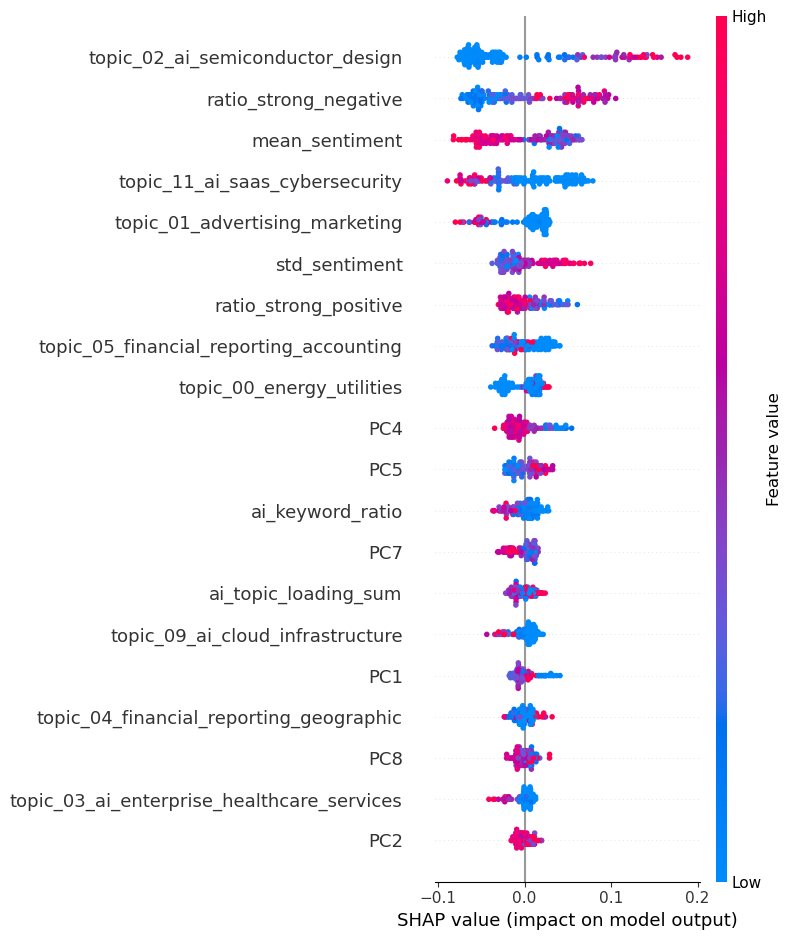

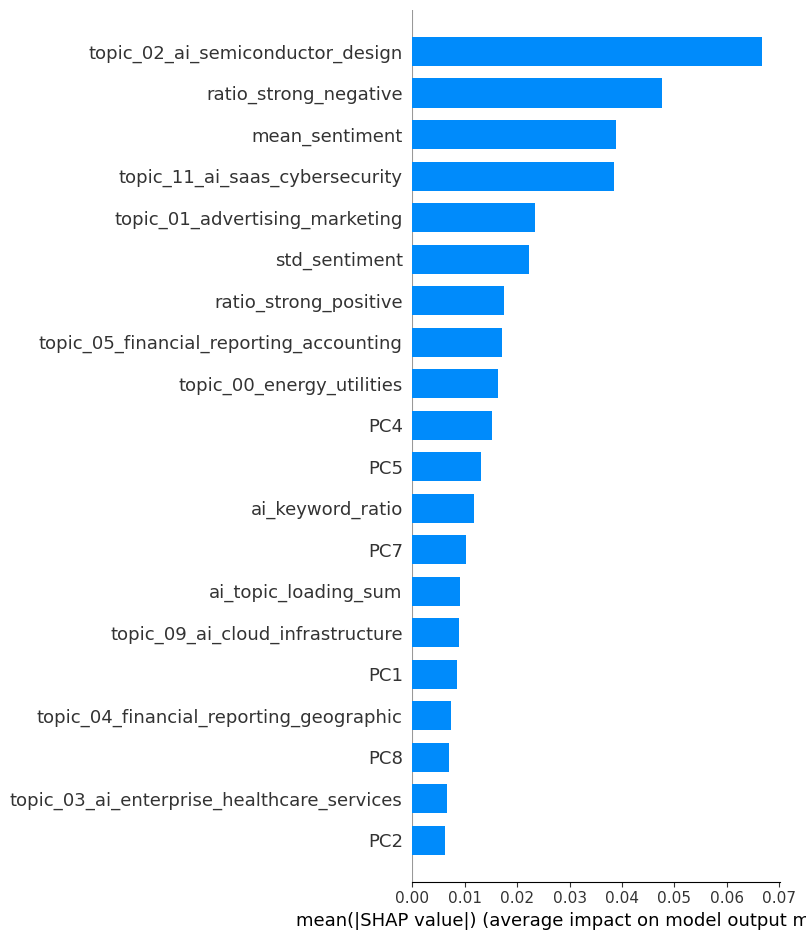


Saved:
  shap_summary_combined_rf.png
  shap_bar_combined_rf.png


In [2]:
# =========================
# SHAP for X_fin_plus_X_text + Random Forest
# =========================

import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# 1. Load combined modeling dataset
df_combined = pd.read_csv("model_finance_text_combined.csv")

print("df_combined shape:", df_combined.shape)

# 2. Define combined feature columns
drop_combined_cols = {
    "companyid", "companyname", "company_name", "companyid_bridge",
    "ticker", "label", "label_binary", "title",
    "tic", "gvkey", "datadate",
    "pct_positive", "pct_negative", "pct_neutral",
    "mean_p_positive", "mean_p_negative", "mean_p_neutral",
    "ai_keyword_count"
}

combined_feature_cols = [
    c for c in df_combined.columns
    if c not in drop_combined_cols
]

X_combined = df_combined[combined_feature_cols].copy()
y_combined = df_combined["label_binary"].copy()

# 3. Impute missing values
imputer = SimpleImputer(strategy="median")
X_combined_imp = pd.DataFrame(
    imputer.fit_transform(X_combined),
    columns=combined_feature_cols
)

print("X_combined_imp shape:", X_combined_imp.shape)

# 4. Fit Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_combined_imp, y_combined)

# 5. SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_combined_imp)

print("X shape:", X_combined_imp.shape)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    print("SHAP output type: list")
    print("SHAP[0] shape:", shap_values[0].shape)
    print("SHAP[1] shape:", shap_values[1].shape)
    shap_values_vul = shap_values[1]

elif len(shap_values.shape) == 3:
    print("SHAP output type: 3D array")
    print("SHAP shape:", shap_values.shape)

    # Case A: (n_samples, n_features, n_classes)
    if shap_values.shape[0] == X_combined_imp.shape[0] and shap_values.shape[1] == X_combined_imp.shape[1]:
        shap_values_vul = shap_values[:, :, 1]

    # Case B: (n_classes, n_samples, n_features)
    elif shap_values.shape[1] == X_combined_imp.shape[0] and shap_values.shape[2] == X_combined_imp.shape[1]:
        shap_values_vul = shap_values[1, :, :]

    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

elif len(shap_values.shape) == 2:
    print("SHAP output type: 2D array")
    print("SHAP shape:", shap_values.shape)
    shap_values_vul = shap_values

else:
    raise ValueError(f"Unsupported SHAP output format: {type(shap_values)}")

print("Final SHAP matrix shape:", shap_values_vul.shape)

# 6. SHAP summary plot
plt.figure()
shap.summary_plot(shap_values_vul, X_combined_imp, show=False)
plt.tight_layout()
plt.savefig("shap_summary_combined_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. SHAP bar plot
plt.figure()
shap.summary_plot(shap_values_vul, X_combined_imp, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar_combined_rf.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:")
print("  shap_summary_combined_rf.png")
print("  shap_bar_combined_rf.png")